# 地理分析

本笔记本围绕客户所在州和地区，分析销量分布、消费偏好和平均消费水平。
- 各州销量分布热力图
- 地区消费偏好差异
- 不同地区的平均消费水平

## 分析目标
挖掘地理分布规律，辅助区域市场策略和资源配置。

## 数据导入与预处理

导入数据，筛选地理相关字段（Location、消费金额等），并检查缺失值。

In [5]:
# 导入库和数据
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

# 读取数据
df = pd.read_csv('shopping_behavior_updated.csv')

# 选取地理相关字段
geo_cols = ['Location', 'Purchase Amount (USD)', 'Category']
df_geo = df[geo_cols]

# 检查缺失值
print(df_geo.isnull().sum())

Location                 0
Purchase Amount (USD)    0
Category                 0
dtype: int64


## 各州销量分布热力图

统计各州销量，展示地理分布热力图。

In [6]:
# 各州销量统计
state_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN',
    'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR',
    'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX',
    'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

state_sales = df['Location'].value_counts().reset_index()
state_sales.columns = ['State', 'Sales']
state_sales['StateAbbr'] = state_sales['State'].map(state_abbr)

# 地图可视化（plotly）
fig = px.choropleth(state_sales,
                    locations='StateAbbr',
                    locationmode='USA-states',
                    color='Sales',
                    color_continuous_scale='Blues',
                    scope='usa',
                    title='美国各州销量分布热力图')
fig.show()

## 地区消费偏好差异分析

统计各州主要消费类别，展示区域消费偏好。

C:\Users\xuzijian\AppData\Local\Temp\ipykernel_35800\1573715421.py:12: UserWarning:

Glyph 24030 (\N{CJK UNIFIED IDEOGRAPH-5DDE}) missing from font(s) DejaVu Sans.

C:\Users\xuzijian\AppData\Local\Temp\ipykernel_35800\1573715421.py:12: UserWarning:

Glyph 38144 (\N{CJK UNIFIED IDEOGRAPH-9500}) missing from font(s) DejaVu Sans.

C:\Users\xuzijian\AppData\Local\Temp\ipykernel_35800\1573715421.py:12: UserWarning:

Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.

C:\Users\xuzijian\AppData\Local\Temp\ipykernel_35800\1573715421.py:12: UserWarning:

Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.

C:\Users\xuzijian\AppData\Local\Temp\ipykernel_35800\1573715421.py:12: UserWarning:

Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.

C:\Users\xuzijian\AppData\Local\Temp\ipykernel_35800\1573715421.py:12: UserWarning:

Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.

C:\Users\x

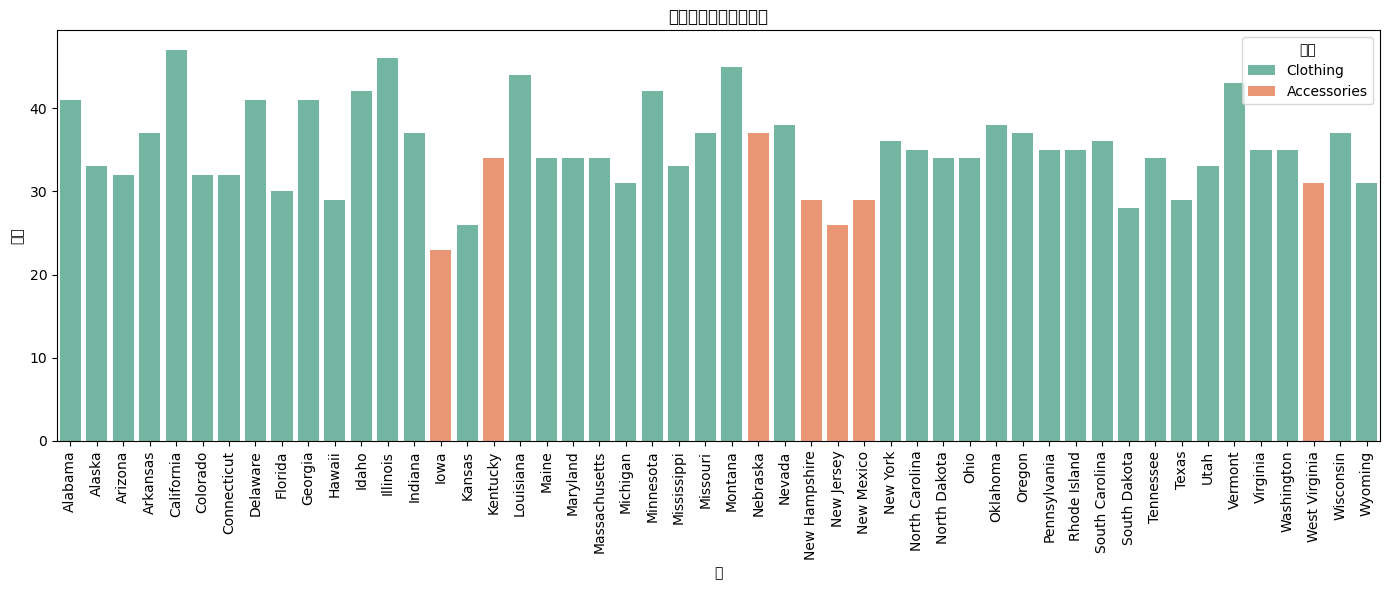

In [7]:
# 各州主要消费类别统计
state_category = df.groupby(['Location', 'Category']).size().reset_index(name='Count')
top_category = state_category.loc[state_category.groupby('Location')['Count'].idxmax()]

plt.figure(figsize=(14,6))
sns.barplot(x='Location', y='Count', hue='Category', data=top_category, dodge=False, palette='Set2')
plt.title('各州主要消费类别分布')
plt.xlabel('州')
plt.ylabel('销量')
plt.xticks(rotation=90)
plt.legend(title='类别')
plt.tight_layout()
plt.show()

## 不同地区的平均消费水平分析

统计各州平均消费金额，并在地图上可视化。

In [10]:
# 各州平均消费金额统计
state_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN',
    'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR',
    'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX',
    'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

state_avg_purchase = df.groupby('Location')['Purchase Amount (USD)'].mean().reset_index()
state_avg_purchase.columns = ['State', 'AvgPurchase']
state_avg_purchase['StateAbbr'] = state_avg_purchase['State'].map(state_abbr)

# 地图可视化（plotly）
fig = px.choropleth(state_avg_purchase,
                    locations='StateAbbr',
                    locationmode='USA-states',
                    color='AvgPurchase',
                    color_continuous_scale='Oranges',
                    scope='usa',
                    title='美国各州平均消费金额分布')
fig.show()

## 结论与建议

- 各州销量和平均消费金额分布差异显著，部分州市场潜力较大。
- 区域消费类别偏好明显，可针对性调整商品结构。
- 地图可视化有助于直观发现高潜力区域和优化资源配置。

建议：结合地理分布规律，制定区域化市场策略，重点投入高消费和高销量州，提升整体业绩。